# Segmentation to Traversability and Path Planning

This notebook is a small, CPU-compatible **prototype** that reuses the trained RGB U-Net. It predicts terrain classes, converts them to configurable provisional pixel costs, and runs A* on one validation image. It is not real rover navigation: physical use also requires camera-to-ground geometry, rover pose/odometry, obstacle and safety constraints, and a real navigation stack.

The cost values below are engineering assumptions, not measured ground-truth traversability. Validation IoU for **Bedrock (class 3)** and **Rock (class 6)** was 0, so those model predictions are unreliable and are assigned the maximum cost conservatively. Do not use this prototype for safety-critical decisions.

## 1. Environment, paths, and configurable choices

The checkpoint and extracted dataset are read from their existing local locations. No package installation, downloads, or training occur here. Adjust the validation index and `(x, y)` start/goal coordinates for another experiment.

In [1]:
import heapq
import math
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

PROJECT_ROOT = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (PROJECT_ROOT, *PROJECT_ROOT.parents) if (p / 'notebooks').is_dir()), PROJECT_ROOT)
DATASET_ROOT = Path.home() / 'data' / 'BASEPROD_labeled' / 'BASEPROD' / 'ORIGINAL'
RGB_DIR = DATASET_ROOT / 'COLOR_IMGS'
MASK_DIR = DATASET_ROOT / 'MASK_RAWS'
CHECKPOINT_PATH = PROJECT_ROOT / 'outputs' / 'segmentation' / 'best_unet_rgb.pt'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'traversability'

IMAGE_SIZE = (256, 256)  # width, height; matches the trained model input.
RANDOM_SEED = 42
NUM_CLASSES = 8
BASE_CHANNELS = 16  # Must match the saved U-Net checkpoint.
VALIDATION_INDEX = 0
START_XY = (5, 5)  # Coordinates are (x, y) in the 256x256 inference grid.
GOAL_XY = (250, 250)
BLOCKED_THRESHOLD = 240  # Predicted cells at or above this cost cannot be entered.
ALLOW_DIAGONAL = True
DEVICE = torch.device('cpu')
CLASS_NAMES = ['Void', 'Compact', 'Grass', 'Bedrock', 'Sandy', 'Pebble', 'Rock', 'Vegetation']
CLASS_COLORS = ['#000000', '#eab676', '#5b9f4a', '#8b8000', '#c04000', '#7393b3', '#e5e4e2', '#74d810']

torch.set_num_threads(max(1, min(4, torch.get_num_threads())))
print(f'Python: {sys.version.split()[0]} | PyTorch: {torch.__version__} | device: {DEVICE}')
print(f'Dataset RGB directory: {RGB_DIR}')
print(f'Checkpoint: {CHECKPOINT_PATH}')
if not torch.cuda.is_available():
    print('CUDA unavailable; inference and planning will use CPU.')
if not RGB_DIR.is_dir() or not MASK_DIR.is_dir():
    raise FileNotFoundError(f'Expected the verified extracted dataset folders. Missing RGB or mask directory under: {DATASET_ROOT}')
if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(f'Trained checkpoint was not found: {CHECKPOINT_PATH}')

Python: 3.12.7 | PyTorch: 2.14.1+cpu | device: cpu
Dataset RGB directory: C:\Users\Anushka\data\BASEPROD_labeled\BASEPROD\ORIGINAL\COLOR_IMGS
Checkpoint: C:\Users\Anushka\UA-MTSeg-Rover-Navigation\UA-MTSeg-Rover-Navigation\outputs\segmentation\best_unet_rgb.pt
CUDA unavailable; inference and planning will use CPU.


## 2. Rebuild the verified validation split and RGB/mask pairs

The verified pairing is `COLOR_IMGS/<timestamp>.png` with `MASK_RAWS/<timestamp>_mask.png`. We require exact matching timestamp keys and single-channel masks. The existing notebook used a reproducible random 80/20 split with `random.Random(42)`, shuffling sorted paired samples and taking the first 190 for validation; that same ordering is reconstructed below.

In [3]:
rgb_by_key = {path.stem: path for path in RGB_DIR.glob('*.png')}
mask_by_key = {path.stem.removesuffix('_mask'): path for path in MASK_DIR.glob('*_mask.png')}
if not rgb_by_key or not mask_by_key:
    raise FileNotFoundError('No PNG RGB images or *_mask.png masks were found in the verified dataset folders.')
if set(rgb_by_key) != set(mask_by_key):
    missing_masks = sorted(set(rgb_by_key) - set(mask_by_key))[:5]
    missing_rgb = sorted(set(mask_by_key) - set(rgb_by_key))[:5]
    raise ValueError(f'RGB/mask timestamp keys do not match. Missing masks examples={missing_masks}; missing RGB examples={missing_rgb}')

samples = [{'key': key, 'rgb_path': rgb_by_key[key], 'mask_path': mask_by_key[key]} for key in sorted(rgb_by_key)]
if len(samples) != 950:
    raise ValueError(f'Expected the previously verified 950 RGB/mask pairs, found {len(samples)}. Re-check the dataset before planning.')
rng = random.Random(RANDOM_SEED)
shuffled_samples = list(samples)
rng.shuffle(shuffled_samples)
validation_count = max(1, int(round(0.2 * len(shuffled_samples))))
validation_samples = shuffled_samples[:validation_count]
if not 0 <= VALIDATION_INDEX < len(validation_samples):
    raise IndexError(f'VALIDATION_INDEX={VALIDATION_INDEX} is outside 0..{len(validation_samples) - 1}.')

sample = validation_samples[VALIDATION_INDEX]
with Image.open(sample['rgb_path']) as image:
    original_rgb = image.convert('RGB')
    original_size = original_rgb.size
    rgb = original_rgb.resize(IMAGE_SIZE, resample=Image.Resampling.BILINEAR)
    rgb_array = np.asarray(rgb, dtype=np.uint8)
with Image.open(sample['mask_path']) as mask_image:
    if len(np.asarray(mask_image).shape) != 2:
        raise ValueError(f'Expected a single-channel segmentation mask: {sample["mask_path"]}')
    if mask_image.size != original_size:
        raise ValueError(f'Paired RGB/mask dimensions differ: RGB={original_size}, mask={mask_image.size}')

print(f'Verified pairs: {len(samples)} | train: {len(samples) - len(validation_samples)} | validation: {len(validation_samples)}')
print(f'Validation sample {VALIDATION_INDEX}: {sample["key"]}')
print(f'Original dimensions: {original_size}; inference/planning grid (width, height): {IMAGE_SIZE}')
print(f'Pair: {sample["rgb_path"].name} <-> {sample["mask_path"].name}')

Verified pairs: 950 | train: 760 | validation: 190
Validation sample 0: 168995504168600000
Original dimensions: (1280, 720); inference/planning grid (width, height): (256, 256)
Pair: 168995504168600000.png <-> 168995504168600000_mask.png


## 3. Load the existing U-Net and predict semantic classes

This is the same from-scratch U-Net architecture and channel width used to train the saved model. Inference is CPU-only and does not update model weights.

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.layers(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=NUM_CLASSES, base_channels=BASE_CHANNELS):
        super().__init__()
        widths = [base_channels, base_channels * 2, base_channels * 4, base_channels * 8]
        self.enc1 = ConvBlock(in_channels, widths[0])
        self.enc2 = ConvBlock(widths[0], widths[1])
        self.enc3 = ConvBlock(widths[1], widths[2])
        self.enc4 = ConvBlock(widths[2], widths[3])
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(widths[3], widths[3] * 2)
        self.up4 = nn.ConvTranspose2d(widths[3] * 2, widths[3], kernel_size=2, stride=2)
        self.dec4 = ConvBlock(widths[3] * 2, widths[3])
        self.up3 = nn.ConvTranspose2d(widths[3], widths[2], kernel_size=2, stride=2)
        self.dec3 = ConvBlock(widths[2] * 2, widths[2])
        self.up2 = nn.ConvTranspose2d(widths[2], widths[1], kernel_size=2, stride=2)
        self.dec2 = ConvBlock(widths[1] * 2, widths[1])
        self.up1 = nn.ConvTranspose2d(widths[1], widths[0], kernel_size=2, stride=2)
        self.dec1 = ConvBlock(widths[0] * 2, widths[0])
        self.classifier = nn.Conv2d(widths[0], num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat((self.up4(b), e4), dim=1))
        d3 = self.dec3(torch.cat((self.up3(d4), e3), dim=1))
        d2 = self.dec2(torch.cat((self.up2(d3), e2), dim=1))
        d1 = self.dec1(torch.cat((self.up1(d2), e1), dim=1))
        return self.classifier(d1)


checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=True)
if 'model_state_dict' not in checkpoint:
    raise KeyError(f'Checkpoint does not contain model_state_dict: {CHECKPOINT_PATH}')
model = UNet().to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
input_tensor = torch.from_numpy(np.ascontiguousarray(rgb_array.transpose(2, 0, 1))).float().div_(255.0).unsqueeze(0).to(DEVICE)
with torch.inference_mode():
    logits = model(input_tensor)
    predicted_mask = logits.argmax(dim=1)[0].cpu().numpy().astype(np.uint8)
if logits.shape != (1, NUM_CLASSES, IMAGE_SIZE[1], IMAGE_SIZE[0]):
    raise ValueError(f'Unexpected model output shape: {tuple(logits.shape)}')
if not set(np.unique(predicted_mask).tolist()).issubset(set(range(NUM_CLASSES))):
    raise ValueError(f'Model produced unexpected class IDs: {np.unique(predicted_mask).tolist()}')
print(f'Prediction shape: {predicted_mask.shape}; predicted class IDs: {np.unique(predicted_mask).tolist()}')

Prediction shape: (256, 256); predicted class IDs: [0, 1, 2, 4, 5, 7]


## 4. Map predicted classes to provisional traversability costs

Cost `0` means least costly and `255` means maximum cost. At the configured blocked threshold (`240`), Void, Bedrock, and Rock predictions are treated as blocked. Their costs are editable assumptions, not learned properties. In particular, Bedrock and Rock have validation IoU 0, so their predicted locations must not be trusted for safety-critical obstacle avoidance.

In [5]:
CLASS_COSTS = {
    0: 255,  # Void: unknown; conservatively blocked.
    1: 30,   # Compact: provisional lower cost.
    2: 80,   # Grass: provisional moderate-low cost.
    3: 255,  # Bedrock: conservative maximum; validation IoU is 0.
    4: 160,  # Sandy: provisional high cost.
    5: 130,  # Pebble: provisional moderate-high cost.
    6: 255,  # Rock: conservative maximum; validation IoU is 0.
    7: 180,  # Vegetation: provisional high cost.
}
if set(CLASS_COSTS) != set(range(NUM_CLASSES)) or any(not 0 <= value <= 255 for value in CLASS_COSTS.values()):
    raise ValueError('CLASS_COSTS must provide one integer cost in 0..255 for each class ID 0..7.')
cost_map = np.zeros_like(predicted_mask, dtype=np.uint8)
for class_id, cost in CLASS_COSTS.items():
    cost_map[predicted_mask == class_id] = cost
print('Class cost configuration:')
for class_id, cost in CLASS_COSTS.items():
    print(f'  {class_id} {CLASS_NAMES[class_id]}: {cost}')
print(f'Cost map dimensions: {cost_map.shape}; unique costs present: {np.unique(cost_map).tolist()}')

Class cost configuration:
  0 Void: 255
  1 Compact: 30
  2 Grass: 80
  3 Bedrock: 255
  4 Sandy: 160
  5 Pebble: 130
  6 Rock: 255
  7 Vegetation: 180
Cost map dimensions: (256, 256); unique costs present: [30, 80, 130, 160, 180, 255]


## 5. Cost-aware grid planning with A*

A* uses four-neighbor or eight-neighbor moves. Each move accumulates the average endpoint terrain cost, multiplied by its grid distance. Cells at or above the blocked threshold cannot be entered; diagonal moves cannot cut across blocked corners. Coordinates use `(x, y)` while NumPy indexing uses `[y, x]`.

In [6]:
def astar_path(costs, start_xy, goal_xy, blocked_threshold=240, allow_diagonal=True):
    height, width = costs.shape
    for name, (x, y) in (('start', start_xy), ('goal', goal_xy)):
        if not (0 <= x < width and 0 <= y < height):
            raise ValueError(f'{name} coordinate {(x, y)} is outside map bounds {width}x{height}.')
        if int(costs[y, x]) >= blocked_threshold:
            raise ValueError(f'{name} coordinate {(x, y)} is blocked with cost {int(costs[y, x])}.')
    if start_xy == goal_xy:
        return [start_xy], 0.0

    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    if allow_diagonal:
        moves += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
    free_costs = costs[costs < blocked_threshold]
    minimum_cost = float(free_costs.min()) if free_costs.size else 0.0

    def heuristic(x, y):
        if allow_diagonal:
            distance = math.hypot(goal_xy[0] - x, goal_xy[1] - y)
        else:
            distance = abs(goal_xy[0] - x) + abs(goal_xy[1] - y)
        return minimum_cost * distance

    start_x, start_y = start_xy
    frontier = [(heuristic(start_x, start_y), 0.0, start_y, start_x)]
    best_cost = {start_xy: 0.0}
    parent = {}
    closed = set()
    while frontier:
        _, path_cost, y, x = heapq.heappop(frontier)
        current = (x, y)
        if current in closed:
            continue
        if current == goal_xy:
            path = [goal_xy]
            while path[-1] != start_xy:
                path.append(parent[path[-1]])
            path.reverse()
            return path, path_cost
        closed.add(current)

        for dx, dy in moves:
            nx, ny = x + dx, y + dy
            neighbor = (nx, ny)
            if not (0 <= nx < width and 0 <= ny < height):
                continue
            if int(costs[ny, nx]) >= blocked_threshold or neighbor in closed:
                continue
            if dx and dy and (int(costs[y, nx]) >= blocked_threshold or int(costs[ny, x]) >= blocked_threshold):
                continue
            step_distance = math.sqrt(2) if dx and dy else 1.0
            next_cost = path_cost + step_distance * (int(costs[y, x]) + int(costs[ny, nx])) / 2.0
            if next_cost < best_cost.get(neighbor, float('inf')):
                best_cost[neighbor] = next_cost
                parent[neighbor] = current
                priority = next_cost + heuristic(nx, ny)
                heapq.heappush(frontier, (priority, next_cost, ny, nx))
    return None, float('inf')


path, accumulated_cost = astar_path(cost_map, START_XY, GOAL_XY, BLOCKED_THRESHOLD, ALLOW_DIAGONAL)
path_found = path is not None
path_steps = max(0, len(path) - 1) if path_found else 0
geometric_path_length = sum(math.hypot(b[0] - a[0], b[1] - a[1]) for a, b in zip(path, path[1:])) if path_found else 0.0
print(f'Image/planning grid: {cost_map.shape[1]}x{cost_map.shape[0]} pixels')
print(f'Start (x, y): {START_XY}; goal (x, y): {GOAL_XY}')
print(f'Path found: {path_found}')
print(f'Path steps: {path_steps}; geometric length: {geometric_path_length:.2f} grid pixels')
print(f'Accumulated cost (cost-pixels): {accumulated_cost:.2f}')

Image/planning grid: 256x256 pixels
Start (x, y): (5, 5); goal (x, y): (250, 250)
Path found: True
Path steps: 272; geometric length: 366.44 grid pixels
Accumulated cost (cost-pixels): 11168.22


## 6. Visualize and save the prediction, cost map, and route

The route is drawn in the same 256×256 coordinate frame used by the planner. Outputs are saved under `outputs/traversability` in the repository’s outputs folder; the source dataset and trained checkpoint remain unchanged.

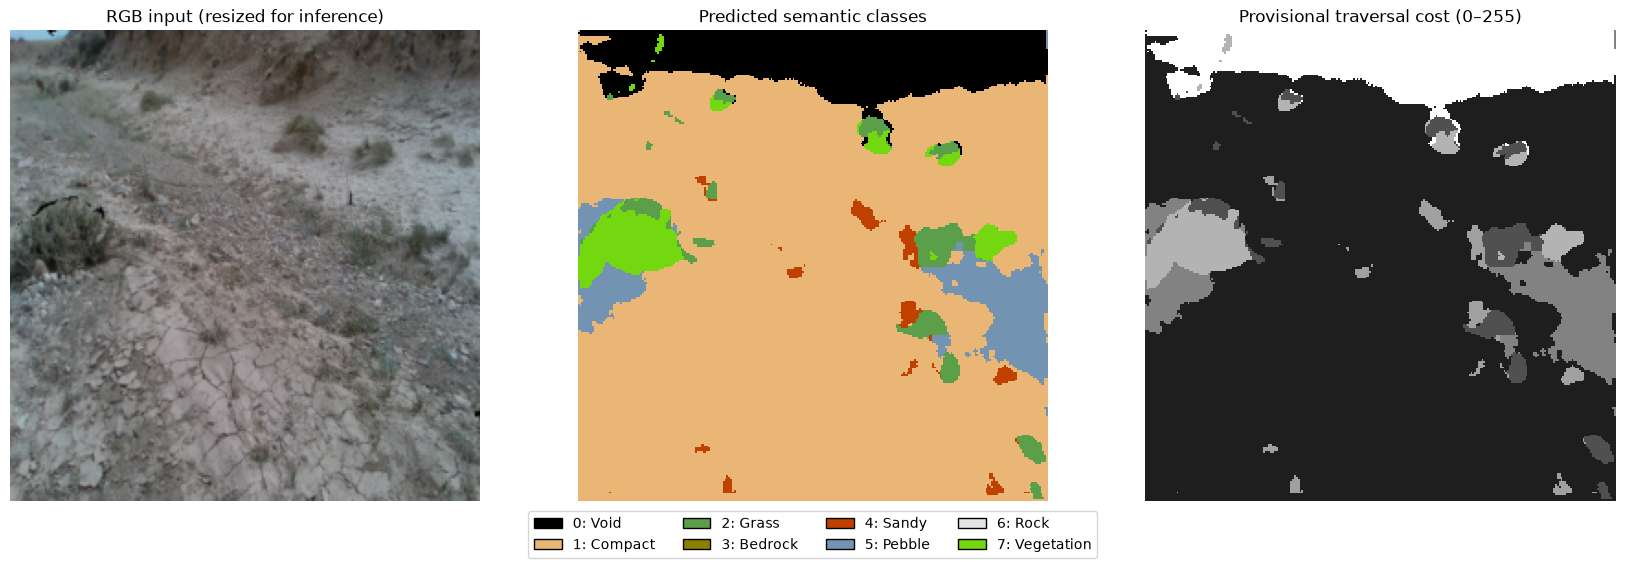

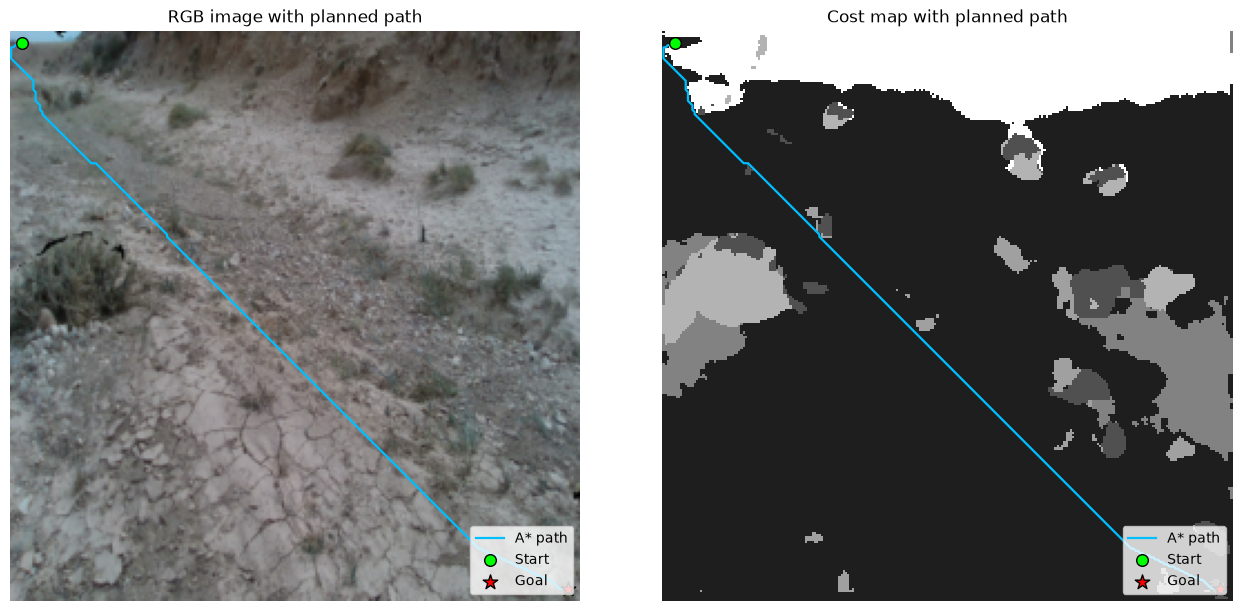

Saved outputs to: C:\Users\Anushka\UA-MTSeg-Rover-Navigation\UA-MTSeg-Rover-Navigation\outputs\traversability
  semantic_cost_map.png: 786,302 bytes
  planned_path.png: 282,240 bytes
  predicted_semantic_mask.png: 2,609 bytes
  traversability_cost_map.png: 2,657 bytes


In [7]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
semantic_cmap = ListedColormap(CLASS_COLORS)
legend_handles = [Patch(facecolor=CLASS_COLORS[i], edgecolor='black', label=f'{i}: {CLASS_NAMES[i]}') for i in range(NUM_CLASSES)]
path_xy = np.asarray(path) if path_found else np.empty((0, 2), dtype=int)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
axes[0].imshow(rgb_array)
axes[0].set_title('RGB input (resized for inference)')
axes[1].imshow(predicted_mask, cmap=semantic_cmap, vmin=0, vmax=NUM_CLASSES - 1, interpolation='nearest')
axes[1].set_title('Predicted semantic classes')
axes[2].imshow(cost_map, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
axes[2].set_title('Provisional traversal cost (0–255)')
for axis in axes:
    axis.axis('off')
fig.legend(handles=legend_handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.savefig(OUTPUT_DIR / 'semantic_cost_map.png', dpi=160, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
axes[0].imshow(rgb_array)
axes[0].set_title('RGB image with planned path')
axes[1].imshow(cost_map, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
axes[1].set_title('Cost map with planned path')
for axis in axes:
    if path_found:
        axis.plot(path_xy[:, 0], path_xy[:, 1], color='deepskyblue', linewidth=1.6, label='A* path')
    axis.scatter(*START_XY, marker='o', s=70, color='lime', edgecolors='black', label='Start', zorder=3)
    axis.scatter(*GOAL_XY, marker='*', s=120, color='red', edgecolors='black', label='Goal', zorder=3)
    axis.set_xlim(-0.5, IMAGE_SIZE[0] - 0.5)
    axis.set_ylim(IMAGE_SIZE[1] - 0.5, -0.5)
    axis.axis('off')
axes[0].legend(loc='lower right')
axes[1].legend(loc='lower right')
fig.savefig(OUTPUT_DIR / 'planned_path.png', dpi=160, bbox_inches='tight')
plt.show()

Image.fromarray(predicted_mask, mode='L').save(OUTPUT_DIR / 'predicted_semantic_mask.png')
Image.fromarray(cost_map, mode='L').save(OUTPUT_DIR / 'traversability_cost_map.png')
print(f'Saved outputs to: {OUTPUT_DIR}')
for name in ('semantic_cost_map.png', 'planned_path.png', 'predicted_semantic_mask.png', 'traversability_cost_map.png'):
    output_path = OUTPUT_DIR / name
    print(f'  {output_path.name}: {output_path.stat().st_size:,} bytes')

## 7. Interpretation and limitations

- The displayed and saved path is a minimum-cost route through a **predicted pixel grid**, not a metric route on the ground.
- Cost assignments and the blocked threshold are provisional choices that should be calibrated and validated before any physical use.
- Bedrock and Rock validation IoU was 0; setting their cost high is conservative, but the model cannot reliably identify them. A predicted label is not a safety guarantee.
- A deployable rover system also needs camera geometry and ground projection, pose/odometry, vehicle footprint and kinematic constraints, dynamic obstacle handling, and an appropriate navigation/control stack.